# Customer Churn Dataset

https://www.kaggle.com/datasets/sonalshinde123/customer-churn-prediction-dataset?resource=download&select=customer_churn_dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Elogroup/CNH data literacy/Adv/customer_churn_dataset.csv")

In [ ]:
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


## Data Cleaning

Drop column that is not relevant for our analysis, and may be sensitive information - customer_id

In [ ]:
df.drop(columns=["customer_id"], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure            20000 non-null  int64  
 1   monthly_charges   20000 non-null  float64
 2   total_charges     20000 non-null  float64
 3   contract          20000 non-null  object 
 4   payment_method    20000 non-null  object 
 5   internet_service  17987 non-null  object 
 6   tech_support      20000 non-null  object 
 7   online_security   20000 non-null  object 
 8   support_calls     20000 non-null  int64  
 9   churn             20000 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 1.5+ MB


We have 20k lines. We have null values on the column "internet_service". The rest don't have null values, and their datatype e according to the information present. We have to treat it. Here, I'll replace it with "Unknown", instaead of the mode or removing the lines or the column.

In [ ]:
df['internet_service'] = df['internet_service'].fillna('Unknown')

In [ ]:
df[df.duplicated()]

,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
19175,22,73.69,1621.18,Month-to-month,UPI,DSL,No,No,2,Yes


There is one duplicated line. We will drop it.

In [ ]:
df.drop_duplicates(inplace=True)

## EDA - Exploratory Data Analysis

Let's now do a brief exploratory analysis to understand the data.

In [ ]:
df.describe(include="all")

,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
count,19999.000000,19999.000000,19999.000000,19999,19999,19999,19999,19999,19999.000000,19999
unique,NaN,NaN,NaN,3,4,3,2,2,NaN,2
top,NaN,NaN,NaN,Month-to-month,Credit,Fiber,No,No,NaN,No
freq,NaN,NaN,NaN,11941,5026,10064,13030,12007,NaN,13157
mean,36.468173,70.010347,2544.025351,NaN,NaN,NaN,NaN,NaN,1.512526,NaN
std,20.774252,28.890950,1882.985574,NaN,NaN,NaN,NaN,NaN,1.235266,NaN
min,1.000000,20.000000,20.230000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,18.000000,45.210000,1045.825000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
50%,36.000000,70.090000,2096.500000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
75%,54.000000,95.075000,3690.495000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN


In [ ]:
num_cols = df.select_dtypes(include="number").columns.tolist()

cat_cols = df.select_dtypes(exclude="number").columns.tolist()


print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

Categorical columns: ['contract', 'payment_method', 'internet_service', 'tech_support', 'online_security', 'churn']
Numerical columns: ['tenure', 'monthly_charges', 'total_charges', 'support_calls']


Plots for the target variable: churn, and also for all the numeric and categorical values.

In [ ]:
# @title
import plotly.express as px

target = "churn"

fig = px.histogram(
    df,
    x=target,
    title="Churn Distribution",
    text_auto=True
)

fig.show()

**Class Distribution**

In this dataset, the target has a **65/35 split**. While it is slightly imbalanced, the difference is **not severe**.  

For now, we will **leave the dataset as is**. Later, during model training, we can test whether techniques like **undersampling** improve performance metrics, and decide based on the results.

In [ ]:
# @title
import plotly.graph_objects as go
from plotly.subplots import make_subplots

target = "churn"

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Distribution", "Boxplot by Churn")
)

for i, col in enumerate(num_cols):
    fig.add_trace(
        go.Histogram(
            x=df[col],
            name="Distribution",
            visible=(i == 0)
        ),
        row=1,
        col=1
    )

    fig.add_trace(
        go.Box(
            x=df[target],
            y=df[col],
            name="Boxplot",
            visible=(i == 0)
        ),
        row=1,
        col=2
    )

buttons = []

for i, col in enumerate(num_cols):
    visible = [False] * len(fig.data)
    visible[2*i] = True
    visible[2*i + 1] = True

    buttons.append(
        dict(
            label=col,
            method="update",
            args=[
                {"visible": visible},
                {
                    "title.text": f"Numerical Analysis: {col}",
                    "xaxis.title.text": col,
                    "yaxis2.title.text": col
                }
            ]
        )
    )

fig.update_layout(
    title=f"Numerical Analysis: {num_cols[0]}",
    height=500,
    width=1200,
    updatemenus=[
        dict(
            buttons=buttons,
            x=1.2,
            y=1.2
        )
    ]
)

fig.update_xaxes(title_text=num_cols[0], row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)

fig.update_xaxes(title_text=target, row=1, col=2)
fig.update_yaxes(title_text=num_cols[0], row=1, col=2)

fig.show()

We can extract interesting information from the numerical variables.

- tenure
  - goes from 1 to 72 years of company.
  - uniformly distributed.
  - When churn is yes, it has slightly lower median. Meaning that people with lower tenure are a little more likely to churn
- monthly charges
  - goes from 20 to 120 dollars.
  - uniformly distributed.
  - people who churned have higher monthly charges
- total charges
  - goes from 20 to 8629 dollars.
  - Would be interesting to analyse this in relation to monthly charges and type of charge to see if there is anything incorrect.
  - Very assymetrical normal distribution.
  - People who churn have a interquartile range larger to the bottom and to the top then people who don't churn.
- support calls
  - goes from 0 to 8
  - Assymetrical normal distribution
  - People who churn have higher number of support calls


In [ ]:
# @title
cat_cols_plot = [col for col in cat_cols if col != target]
churn_values = df[target].dropna().unique()

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Distribution", "Distribution by Churn")
)

traces_per_col = 1 + len(churn_values)

for i, col in enumerate(cat_cols_plot):
    visible = i == 0

    counts = df[col].value_counts(dropna=False)

    fig.add_trace(
        go.Bar(
            x=counts.index.astype(str),
            y=counts.values,
            name="Distribution",
            visible=visible
        ),
        row=1,
        col=1
    )

    counts_churn = df.groupby([col, target]).size()

    for churn_value in churn_values:
        subset = counts_churn.xs(churn_value, level=target, drop_level=False)

        fig.add_trace(
            go.Bar(
                x=subset.index.get_level_values(col).astype(str),
                y=subset.values,
                name=f"{target} = {churn_value}",
                visible=visible
            ),
            row=1,
            col=2
        )

buttons = []

for i, col in enumerate(cat_cols_plot):
    visible = [False] * len(fig.data)

    start = i * traces_per_col
    end = start + traces_per_col

    visible[start:end] = [True] * traces_per_col

    buttons.append(
        dict(
            label=col,
            method="update",
            args=[
                {"visible": visible},
                {
                    "title.text": f"Categorical analysis: {col}",
                    "xaxis.title.text": col,
                    "xaxis2.title.text": col
                }
            ]
        )
    )

fig.update_layout(
    title=f"Categorical analysis: {cat_cols_plot[0]}",
    height=500,
    width=1200,
    barmode="group",
    updatemenus=[
        dict(
            buttons=buttons,
            x=1.2,
            y=1.2
        )
    ]
)

fig.update_xaxes(title_text=cat_cols_plot[0], row=1, col=1)
fig.update_xaxes(title_text=cat_cols_plot[0], row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=2)

fig.show()

- contract
  - most are month to month plans (12k - 60%), followed by one year and two years
  - concentration of churning on month to month plans (disproportionate from the actual distribution - 75%)
- payment method
   - uniform distribution
   - don't relate to churn
- internet service
  - most are fiber, followed by DSL and Unknown
  - don't relate to churn
- tech support
  - most people didn't have tech support (13k - 65%)
  - most of the people who churned didn't have tech support (78%)
- online security
  - most don't have online security
  - don't relate to churn

No further cleaning is necessary.

Now we do data transformation for the categorical and numerical variables.

## Categorical Encoding

### Ordinal Encoding

**Ordinal encoding** is used for features where the **order of categories matters**. The goal is to map each category to an integer so that the model can recognize the relative importance or ranking of the values.

**Example:**  
Consider a feature called `Service Priority Level` with categories:

We can encode it as:
```python
{'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
```
In general, ordinal encoding replaces each category with a corresponding number that reflects its order.  

In this dataset, we can do ordinal encoding with the contract method, in terms of years. For example,
```python
{'Month to month': 0, 'One year': 1, 'Two years': 2}
```

---

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

contract_order = [["Month-to-month", "One year", "Two year"]]

encoder = OrdinalEncoder(categories=contract_order)

df["contract"] = encoder.fit_transform(df[["contract"]])

In [ ]:
df.head()

,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,52,54.20,2818.40,0.0,Credit,DSL,No,Yes,1,No
1,15,35.28,529.20,0.0,Debit,DSL,No,No,2,No
2,72,78.24,5633.28,0.0,Debit,DSL,No,No,0,No
3,61,80.24,4894.64,1.0,Cash,Fiber,Yes,Yes,0,No
4,21,39.38,826.98,0.0,UPI,Fiber,No,No,4,Yes


### One-Hot Encoding

One-hot encoding is used for **categorical features where the order of categories does not matter**. Each category is treated independently, so the model does not assume any ranking.

**Example 1: `contract` column**

**Before encoding:**

| contract       |
|----------------|
| Month-to-month |
| One year       |
| Two year       |

**After one-hot encoding:**  
Each category is represented by a fixed binary array:

- `Month-to-month` → `[1, 0, 0]`  
- `One year` → `[0, 1, 0]`  
- `Two year` → `[0, 0, 1]`  

| Month-to-month | One year | Two year |
|----------------|----------|----------|
| 1              | 0        | 0        |
| 0              | 1        | 0        |
| 0              | 0        | 1        |

---

**Example 2: `internet_service` column (binary feature)**

**Before encoding:**

| internet_service |
|-----------------|
| Fiber           |
| DSL             |
| Fiber           |

**After encoding (single binary column):**  
For binary features, one category is represented as `1` and the other as `0`:

- `Fiber` → `1`  
- `DSL` → `0`  

| internet_service_Fiber |
|------------------------|
| 1                      |
| 0                      |
| 1                      |

> **Attention:**  
> For features with only **two categories**, creating two one-hot columns is **redundant**. We only need one column, with one category as `0` and the other as `1`. Also, for three categories, we only need two columns, if 0, 0 it is the other, now the information is already encoded. So, we do **drop first**.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

onehot_cols = [
    col for col in cat_cols
    if col != "contract" and col != target
]

onehot_encoder = OneHotEncoder(drop='first')

X_onehot = onehot_encoder.fit_transform(df[onehot_cols])
df_onehot = pd.DataFrame(
    X_onehot.toarray(),
    columns = onehot_encoder.get_feature_names_out(onehot_cols),
    index = df.index
)
df_onehot

,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_Fiber,internet_service_Unknown,tech_support_Yes,online_security_Yes
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
19995,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19996,0.0,0.0,1.0,1.0,0.0,1.0,0.0
19997,1.0,0.0,0.0,1.0,0.0,0.0,0.0
19998,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df = df.drop(columns=onehot_cols)

df = pd.concat(
    [df, df_onehot],
    axis=1
)
df.head()

,tenure,monthly_charges,total_charges,contract,support_calls,churn,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_Fiber,internet_service_Unknown,tech_support_Yes,online_security_Yes
0,52,54.20,2818.40,0.0,1,No,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,15,35.28,529.20,0.0,2,No,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,72,78.24,5633.28,0.0,0,No,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,61,80.24,4894.64,1.0,0,No,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,21,39.38,826.98,0.0,4,Yes,0.0,0.0,1.0,1.0,0.0,0.0,0.0


> **Attention!**  
>
> When a column has **many categories**—for example, +100 unique values—using one-hot encoding becomes inefficient. One-hot encoding would create **+100 new columns**, one for each category, which can:
> - Significantly slow down model training  
> - Make the dataset very sparse  
> - Cause the model to struggle or “get stuck”  
>
> This problem is known as the **curse of dimensionality**.  
>
> Modern techniques, such as **embeddings**, can handle high-cardinality categorical features more efficiently. If you’re interested, you can explore embeddings to represent these features in a lower-dimensional space while preserving their information.

### Target / Label Encoding

Now that most of our features are prepared for modeling, we need to prepare the **target variable** for our supervised classification model. The target variable contains the **true labels** that the model will try to predict. In this dataset, the target is the `churn` column, which indicates whether a customer has churned or not.

Since models cannot directly work with text values like `"Yes"` or `"No"`, we need to **convert the target into numbers**.  

Because this is a **binary classification problem**, we encode the target as follows:

- `"Yes"` → `1` (customer churned)  
- `"No"` → `0` (customer did not churn)  

This allows the model to learn from the features and predict `0` or `1` for churn.


In [ ]:
# Map values of the churn column
# Map and cast to int explicitly
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0}).astype(int)

# Putting the target column as the last column it is a standard and help us futher.
# Reorder columns: move 'churn' to the end
cols = [c for c in df.columns if c != 'churn'] + ['churn']
df = df[cols]
df.head()

,tenure,monthly_charges,total_charges,contract,support_calls,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_Fiber,internet_service_Unknown,tech_support_Yes,online_security_Yes,churn
0,52,54.20,2818.40,0.0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,15,35.28,529.20,0.0,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,72,78.24,5633.28,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,61,80.24,4894.64,1.0,0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0
4,21,39.38,826.98,0.0,4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1


**What if our model was multiclass or multilabel?**

In this example, we have a **binary classification problem** (`churn`: Yes/No). But if our target had **more than two classes** (multiclass) or **multiple labels per sample** (multilabel), we would need to encode the target differently.

## Train val test split

Train the model with train set, then evaluate with the validation set. Compare all the models and configurations, adjust hyperparameters. After all of that, we use the test set to make final predictions and check the expected result on real world unseen data for the final model.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

# Step 1: Train + Temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,           # 30% goes to temp (val + test)
    stratify=y,              # preserve class distribution
    shuffle=True,
    random_state=42
)

# Step 2: Split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,           # half of temp -> test, half -> validation
    stratify=y_temp,
    shuffle=True,
    random_state=42
)

# Check sizes - 70% train / 15% valid / 15% test
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (13999, 12) Validation: (3000, 12) Test: (3000, 12)


**Attention!**

When training a **classification model**, it is generally beneficial to **shuffle the rows** before splitting the dataset.  

- Unlike time series models, **the order of the data does not matter** in classification. Shuffling increases diversity in the training data and helps the model generalize better.  
- Another important point is the **`stratify` parameter** in train/validation/test splits.  
  - Using `stratify=y` ensures that the **target distribution is preserved** across all splits.  
  - Without stratification, you could end up with a training set that contains mostly class 0 and very few (or no) examples of class 1, which can harm model performance.  
- In short, **shuffling + stratification** ensures your model sees a **representative and balanced distribution of classes** in all splits.


## Normalization or Standardization

use fit_transform only on X_train, and only transform on X_val and X_test, to avoid data leakage.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Train the Classification Models

Each model has its own characteristics, advantages and limitations.


### Models
#### Logistic Regression

Simple and interpretable model that estimates the probability of a class.

**Advantages:** fast, easy to explain, good baseline.  
**Limitations:** works better when the decision boundary is approximately linear.

#### KNN

Classifies a new example based on the most similar examples in the training data.

**Advantages:** intuitive and captures non-linear patterns.  
**Limitations:** sensitive to scaling and can be slow with large datasets.

#### Decision Tree

Uses a sequence of rules to classify observations.

**Advantages:** easy to visualize and explain.  
**Limitations:** can overfit the training data.

#### Random Forest

Combines many decision trees to make a more robust prediction.

**Advantages:** strong performance and less overfitting than one tree.  
**Limitations:** less interpretable than a single tree.

#### Gradient Boosting

Builds trees sequentially, where each tree tries to correct previous errors. Here we will use the Gradient Boosting class from sklearn, but there are other more powerful implementations, such as XGBoost - test it later on and see if it makes a difference for this dataset.

**Advantages:** usually very accurate for tabular data.  
**Limitations:** more sensitive to hyperparameters.



_There is no single best model. We compare different algorithms to balance performance, interpretability and business impact._

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

### Model Evaluation Summary

The models can be evaluated using accuracy, precision, recall, F1-score and the confusion matrix.

**Accuracy** shows the overall proportion of correct predictions. However, in churn prediction, accuracy alone is not enough, because the dataset may be imbalanced.

**Precision** shows how reliable the churn predictions are. A high precision means that, when the model predicts churn, it is usually correct. So, high precision means the model does not raise many false alarms.

**Recall** tells us how many customers who actually churned were correctly found by the model. Usually, in churn prediction, recall is very important because missing a customer who will leave can be more costly than contacting a customer who would not leave.

The **F1-score** combines precision and recall into a single metric, helping compare models when both false positives and false negatives matter. Useful to try to miss as little churn customers as possible, as well as saving money from not doing useless campaings.

The confusion matrix gives a more detailed view of the errors:

- True Negatives: customers who did not churn and were correctly classified.
- False Positives: customers who did not churn but were predicted as churn.
- False Negatives: customers who churned but were missed by the model.
- True Positives: customers who churned and were correctly classified.

For a churn prediction model, false negatives are usually more critical because the company may lose customers without taking preventive action.

In [ ]:
trained_models = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(y_test, y_pred))
    print()

Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.90      0.84      1973
           1       0.73      0.53      0.61      1027

    accuracy                           0.77      3000
   macro avg       0.76      0.71      0.73      3000
weighted avg       0.77      0.77      0.76      3000


KNN
              precision    recall  f1-score   support

           0       0.79      0.91      0.85      1973
           1       0.76      0.55      0.63      1027

    accuracy                           0.78      3000
   macro avg       0.78      0.73      0.74      3000
weighted avg       0.78      0.78      0.77      3000


Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1973
           1       0.61      0.63      0.62      1027

    accuracy                           0.73      3000
   macro avg       0.71      0.71      0.71      3000
weighted avg       0.74      0.73 

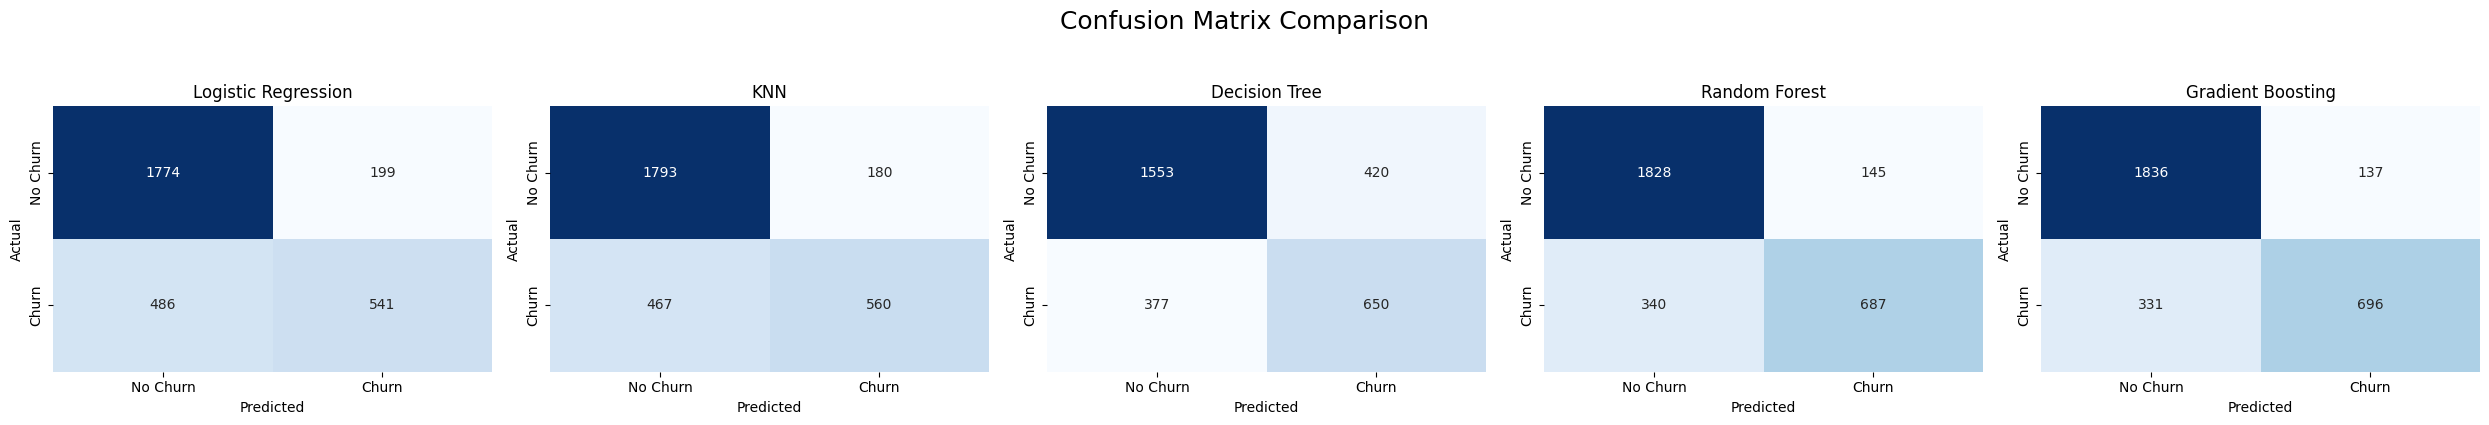

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

class_names = ["No Churn", "Churn"]

n_models = len(predictions)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_models,
    figsize=(5 * n_models, 4)
)

if n_models == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

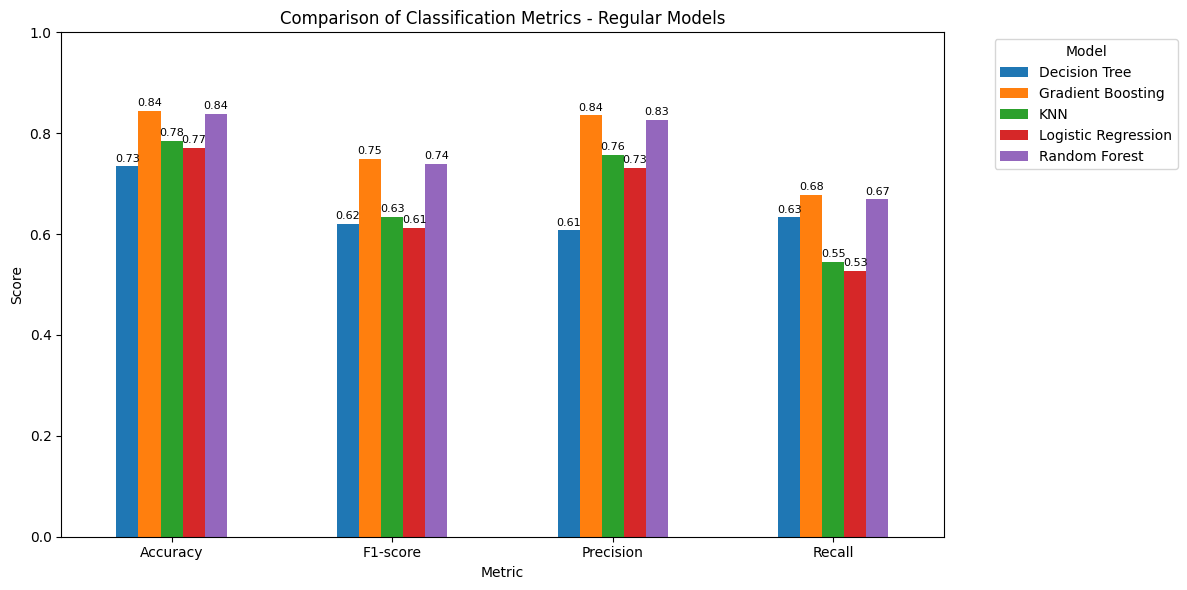

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# Metrics for regular models
# ============================================================

metrics_results = []

for model_name, y_pred in predictions.items():
    metrics_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

metrics_df_regular = pd.DataFrame(metrics_results)

# ============================================================
# Convert to long format
# ============================================================

metrics_long = metrics_df_regular.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

# ============================================================
# Bar plot: x = metrics, hue/color = models
# ============================================================

plot_df = metrics_long.pivot(
    index="Metric",
    columns="Model",
    values="Score"
)

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Comparison of Classification Metrics - Regular Models")
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()

### Class weight balanced

What if we train with the parameter class_weight="balanced"? It will adjust the optimization process to give more importance to the minority class!

Feel free to experiment with different `class_weight` values later to better understand their impact on model performance.

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

models_balanced = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=42,
        class_weight="balanced"
    ),

    # KNN does not have class_weight

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    # GradientBoostingClassifier does not have class_weight directly
    # We will use sample_weight during fit
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [ ]:

trained_models_balanced = {}
predictions_balanced = {}

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

for model_name, model in models_balanced.items():

    if model_name == "Gradient Boosting":
        model.fit(
            X_train_scaled,
            y_train,
            sample_weight=sample_weights
        )
    else:
        model.fit(
            X_train_scaled,
            y_train
        )

    y_pred = model.predict(X_test_scaled)

    trained_models_balanced[model_name] = model
    predictions_balanced[model_name] = y_pred

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.71      0.77      1973
           1       0.57      0.74      0.64      1027

    accuracy                           0.72      3000
   macro avg       0.70      0.72      0.70      3000
weighted avg       0.75      0.72      0.72      3000

Confusion Matrix:
[[1392  581]
 [ 267  760]]

Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1973
           1       0.61      0.61      0.61      1027

    accuracy                           0.73      3000
   macro avg       0.70      0.70      0.70      3000
weighted avg       0.73      0.73      0.73      3000

Confusion Matrix:
[[1567  406]
 [ 397  630]]

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1973
           1       0.82      0.67      0.74      1027

    accuracy                           0.8

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ============================================================
# 1. Create metrics table for regular and balanced models
# ============================================================

all_metrics = []

for model_name, y_pred in predictions.items():
    all_metrics.append({
        "Model": model_name,
        "Version": "Regular",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

for model_name, y_pred in predictions_balanced.items():
    all_metrics.append({
        "Model": model_name,
        "Version": "Balanced",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

metrics_comparison_df = pd.DataFrame(all_metrics)

metrics_comparison_df

# ============================================================
# 2. Convert to long format for Plotly
# ============================================================

metrics_long = metrics_comparison_df.melt(
    id_vars=["Model", "Version"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

metrics_long["Model Version"] = (
    metrics_long["Model"] + " - " + metrics_long["Version"]
)

metrics_long.head()

# ============================================================
# 3. Interactive Plotly plot
# ============================================================

fig = px.bar(
    metrics_long,
    x="Metric",
    y="Score",
    color="Model Version",
    barmode="group",
    text=metrics_long["Score"].round(3),
    hover_data={
        "Model": True,
        "Version": True,
        "Metric": True,
        "Score": ":.3f",
        "Model Version": False
    },
    title="Classification Metrics Comparison: Regular vs Balanced Models"
)

fig.update_layout(
    height=600,
    width=1100,
    yaxis=dict(range=[0, 1]),
    xaxis_title="Metric",
    yaxis_title="Score",
    legend_title="Click models to show/hide",
)

fig.update_traces(
    textposition="outside"
)

fig.show()

### Random Undersampling

What if we make a random undersampling? Let's do the random undersampling, the distribution must be 50/50 after the process.

Make predictions - We need to validate and test on the unbalanced dataset to see the real performance! We never can undersample the validation and test

The library imblearn can help us with it - try other types of under and over sampling from it later.


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(
    sampling_strategy="auto",  # makes classes 50/50
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(
    X_train_scaled,
    y_train
)

print("Before undersampling:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nAfter undersampling:")
print(pd.Series(y_train_under).value_counts(normalize=True))

Before undersampling:
churn
0    0.657904
1    0.342096
Name: proportion, dtype: float64

After undersampling:
churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
trained_models_under = {}
predictions_under = {}

for model_name, model in models.items():
    model.fit(X_train_under, y_train_under)

    # Important: test set remains unbalanced
    y_pred = model.predict(X_test_scaled)

    trained_models_under[model_name] = model
    predictions_under[model_name] = y_pred

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.71      0.77      1973
           1       0.57      0.74      0.64      1027

    accuracy                           0.72      3000
   macro avg       0.70      0.72      0.71      3000
weighted avg       0.75      0.72      0.73      3000

Confusion Matrix:
[[1396  577]
 [ 267  760]]

KNN
              precision    recall  f1-score   support

           0       0.80      0.77      0.79      1973
           1       0.59      0.64      0.61      1027

    accuracy                           0.73      3000
   macro avg       0.70      0.70      0.70      3000
weighted avg       0.73      0.73      0.73      3000

Confusion Matrix:
[[1520  453]
 [ 371  656]]

Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.69      0.75      1973
           1       0.54      0.69      0.60      1027

    accuracy                           0.69      300

In [ ]:
# @title
import pandas as pd
import plotly.express as px

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1. Combine Regular, Class Weight Balanced, and Undersampling
# ============================================================

all_metrics = []

for model_name, y_pred in predictions.items():
    all_metrics.append({
        "Model": model_name,
        "Strategy": "Regular",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

for model_name, y_pred in predictions_balanced.items():
    all_metrics.append({
        "Model": model_name,
        "Strategy": "Class Weight Balanced",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

for model_name, y_pred in predictions_under.items():
    all_metrics.append({
        "Model": model_name,
        "Strategy": "Random Undersampling",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

metrics_all_df = pd.DataFrame(all_metrics)

# ============================================================
# 2. Convert to long format
# ============================================================

metrics_long = metrics_all_df.melt(
    id_vars=["Model", "Strategy"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

metrics_long["Model Strategy"] = (
    metrics_long["Model"] + " - " + metrics_long["Strategy"]
)

# ============================================================
# 3. Plotly barplot with legend control
# ============================================================

fig = px.bar(
    metrics_long,
    x="Metric",
    y="Score",
    color="Model Strategy",
    barmode="group",
    text=metrics_long["Score"].round(3),
    hover_data={
        "Model": True,
        "Strategy": True,
        "Metric": True,
        "Score": ":.3f",
        "Model Strategy": False
    },
    title="Classification Metrics Comparison"
)

fig.update_layout(
    height=650,
    width=1500,
    yaxis=dict(range=[0, 1]),
    xaxis_title="Metric",
    yaxis_title="Score",
    legend_title="Click to show/hide models",
)

fig.update_traces(
    textposition="outside"
)

fig.show()

## Evaluate the final model

Now we pick the best performing model on the validation set. In our case, using the F1-score, it is gradient boosting without using any data agumentation or weights technique.

This is our final model to use. We can evaluate its final result with the test set.

*If we went for the metric recall, as well as general simplicity, we would have picked logistic regression using the balanced weights.*

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Pick the regular Gradient Boosting model
gb_regular = trained_models["Gradient Boosting"]

# Predict on the original test set
y_pred_gb_regular = gb_regular.predict(X_test_scaled)

# Evaluation
print("=" * 70)
print("Gradient Boosting - Regular")
print("=" * 70)

print(classification_report(y_test, y_pred_gb_regular))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb_regular))

print("\nMetrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb_regular))
print("Precision:", precision_score(y_test, y_pred_gb_regular))
print("Recall:", recall_score(y_test, y_pred_gb_regular))
print("F1-score:", f1_score(y_test, y_pred_gb_regular))

Gradient Boosting - Regular
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1973
           1       0.77      0.69      0.73      1027

    accuracy                           0.83      3000
   macro avg       0.81      0.79      0.80      3000
weighted avg       0.82      0.83      0.82      3000

Confusion Matrix:
[[1767  206]
 [ 318  709]]

Metrics:
Accuracy: 0.8253333333333334
Precision: 0.774863387978142
Recall: 0.6903602726387537
F1-score: 0.7301750772399588


How can we interpret this final metrics?

Precision (77%) -> When the model predicts positive/churn it is correct 77% of time

Recall (69%) -> The model detects 69% of all positive cases, but still misses 31% of them (false negative)

## Feature importance

Feature importance helps us understand which input variables contributed the most to the model's predictions.

For tree-based models, such as Gradient Boosting, the model learns a sequence of decision rules using the available features. During training, some features are used more often or produce better splits in the data. These features receive higher importance scores.

A higher feature importance value means that the feature had a stronger influence on the model when separating customers who churned from customers who did not churn.

However, feature importance does not explain whether the feature increases or decreases the probability of churn. It only tells us how useful the feature was for the model.

In this analysis, the most important features are the ones the Gradient Boosting model relied on the most to make churn predictions.

In [ ]:
import pandas as pd
import plotly.express as px

# Get feature importance from regular Gradient Boosting model
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_regular.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance"
)

In [ ]:
fig = px.bar(
    feature_importance_df,
    x="Importance",
    y="Feature",
    orientation="h",
    text="Importance",
    title=f"Feature Importances - Gradient Boosting"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)


fig.show()

It's interesting to observe the features with the highest importance are the ones we analysed that had something to do with churning on EDA.

This is not always true, but shows the importance of those first steps before doing ml.